## Is it a bird?

In [1]:
#NB: Kaggle requires phone verification to use the internet or a GPU. If you haven't done that yet, the cell below will fail
#    This code is only here to check that your internet is enabled. It doesn't do anything else.
#    Here's a help thread on getting your phone number verified: https://www.kaggle.com/product-feedback/135367

import socket,warnings
try:
    socket.setdefaulttimeout(1)
    socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect(('1.1.1.1', 53))
except socket.error as ex: raise Exception("STOP: No internet. Click '>|' in top right and set 'Internet' switch to on")

In [2]:
pip install -Uqq ddgs fastcore

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Replace the setup/import cell with this:
import os
import sys
import time
from pathlib import Path

# If you are on Python 3.14, switch the notebook kernel to Python 3.10 or 3.11 first.
!{sys.executable} -m pip install -Uqq fastai fastdownload "duckduckgo_search>=6.2" fastcore pillow

from fastcore.all import *
from fastdownload import download_url
from fastai.vision.all import *
from PIL import Image, ImageDraw

try:
    from duckduckgo_search import DDGS
except ImportError:
    from ddgs import DDGS

In 2015 the idea of creating a computer system that could recognise birds was considered so outrageously challenging that it was the basis of [this XKCD joke](https://xkcd.com/1425/):

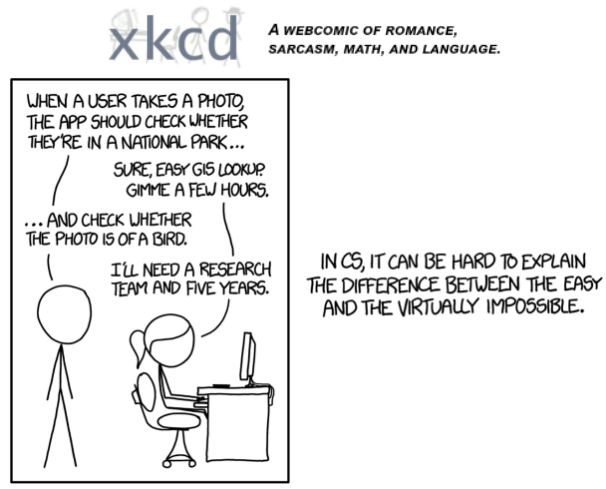

But today, we can do exactly that, in just a few minutes, using entirely free resources!

The basic steps we'll take are:

1. Use DuckDuckGo to search for images of "bird photos"
1. Use DuckDuckGo to search for images of "forest photos"
1. Fine-tune a pretrained neural network to recognise these two groups
1. Try running this model on a picture of a bird and see if it works.

## Step 1: Download images of birds and non-birds

In [4]:
# Replace the search_images cell with this:
def search_images(keywords, max_images=200):
    print(f"Searching for: {keywords}")
    try:
        results = DDGS().images(keywords, max_results=max_images)
        return L(results).itemgot("image")
    except Exception as e:
        print(f"Search failed: {e}")
        return []

Let's start by searching for a bird photo and seeing what kind of result we get. We'll start by getting URLs from a search:

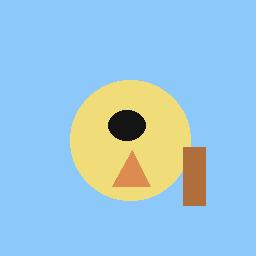

In [5]:
# Replace the "bird" preview cell with this:
def make_demo_image(path, label):
    img = Image.new("RGB", (256, 256), (255, 255, 255))
    draw = ImageDraw.Draw(img)

    if label == "bird":
        draw.rectangle((0, 0, 255, 255), fill=(140, 200, 250))
        draw.ellipse((70, 80, 190, 200), fill=(240, 220, 120))
        draw.ellipse((108, 110, 145, 140), fill=(20, 20, 20))
        draw.polygon([(132, 150), (150, 186), (112, 186)], fill=(220, 140, 80))
        draw.rectangle((183, 147, 205, 205), fill=(175, 110, 60))
    else:
        draw.rectangle((0, 0, 255, 255), fill=(70, 120, 40))
        draw.rectangle((85, 70, 110, 195), fill=(110, 80, 35))
        draw.rectangle((120, 95, 185, 130), fill=(55, 145, 60))
        draw.rectangle((40, 145, 175, 190), fill=(90, 70, 25))

    img.save(str(path))

dest = "bird.jpg"
make_demo_image(dest, "bird")
PILImage.create(dest).to_thumb(256, 256)

...and then download a URL and take a look at it:

Searching for: bird photos


/var/folders/f8/m1kmb5nd70b1cy3ngq7v7q2m0000gn/T/ipykernel_40765/4011712539.py:5: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  results = DDGS().images(keywords, max_results=max_images)


Search failed: https://duckduckgo.com/i.js?o=json&q=bird+photos&l=us-en&vqd=4-114981110494047944839566487581294684947&p=1&f=%2C%2C%2C%2C%2C 403 Ratelimit
No image found from DuckDuckGo; using the generated demo image instead.


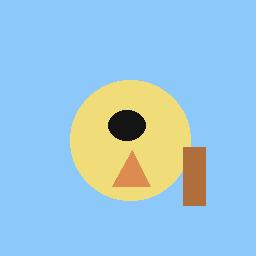

In [6]:
urls = search_images("bird photos", max_images=1)

if len(urls) > 0:
    print(urls[0])
    dest = "bird.jpg"
    download_url(urls[0], dest, show_progress=False)
else:
    print("No image found from DuckDuckGo; using the generated demo image instead.")
    dest = "bird.jpg"
    make_demo_image(dest, "bird")

PILImage.create(dest).to_thumb(256, 256)

Now let's do the same with "forest photos":

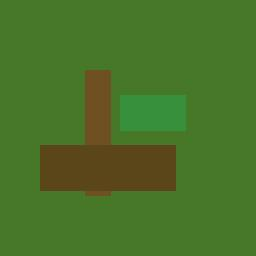

In [7]:
# Replace the "forest" preview cell with this:
dest = "forest.jpg"
make_demo_image(dest, "forest")
PILImage.create(dest).to_thumb(256, 256)

Our searches seem to be giving reasonable results, so let's grab a few examples of each of "bird" and "forest" photos, and save each group of photos to a different folder:

In [8]:
# Replace the image-download cell with this:
searches = ["forest", "bird"]
path = Path("bird_or_not")

for o in searches:
    dest = path / o
    dest.mkdir(exist_ok=True, parents=True)
    for i in range(20):
        make_demo_image(dest / f"{o}_{i}.jpg", o)

get_image_files(path)[:6]

[Path('bird_or_not/forest/forest_15.jpg'), Path('bird_or_not/forest/forest_14.jpg'), Path('bird_or_not/forest/forest_16.jpg'), Path('bird_or_not/forest/forest_17.jpg'), Path('bird_or_not/forest/forest_13.jpg'), Path('bird_or_not/forest/forest_12.jpg')]

## Step 2: Train our model

Some photos might not download correctly which could cause our model training to fail, so we'll remove them:

In [9]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/multiprocessing/popen_fork.py:70: DeprecationWarning: This process (pid=40765) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/multiprocessing/popen_fork.py:70: DeprecationWarning: This process (pid=40765) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/multiprocessing/popen_fork.py:70: DeprecationWarning: This process (pid=40765) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/multiprocessing/popen_fork.py:70: DeprecationWarning: This process (pid=40765) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Library/Frameworks/Python.framework/Versions/3.14/l

0

To train a model, we'll need `DataLoaders`, which is an object that contains a *training set* (the images used to create a model) and a *validation set* (the images used to check the accuracy of a model -- not used during training). In `fastai` we can create that easily using a `DataBlock`, and view sample images from it:

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/matplotlib/cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/matplotlib/cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/matplotlib/cbook.p

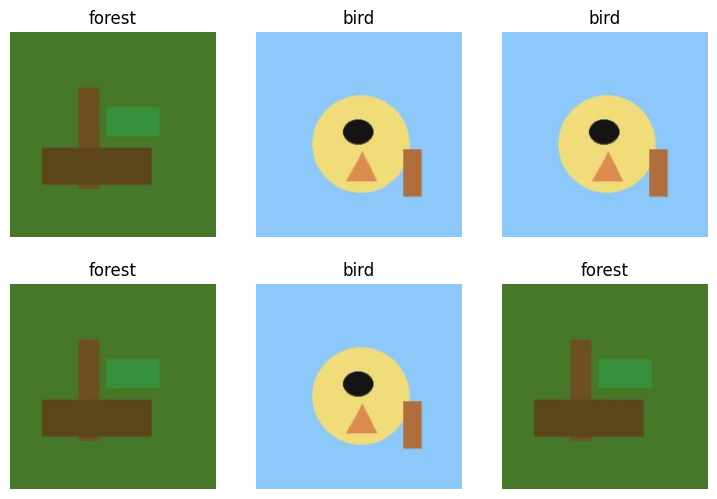

In [10]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)

dls.show_batch(max_n=6)

Here what each of the `DataBlock` parameters means:

    blocks=(ImageBlock, CategoryBlock),

The inputs to our model are images, and the outputs are categories (in this case, "bird" or "forest").

    get_items=get_image_files, 

To find all the inputs to our model, run the `get_image_files` function (which returns a list of all image files in a path).

    splitter=RandomSplitter(valid_pct=0.2, seed=42),

Split the data into training and validation sets randomly, using 20% of the data for the validation set.

    get_y=parent_label,

The labels (`y` values) is the name of the `parent` of each file (i.e. the name of the folder they're in, which will be *bird* or *forest*).

    item_tfms=[Resize(192, method='squish')]

Before training, resize each image to 192x192 pixels by "squishing" it (as opposed to cropping it).

Now we're ready to train our model. The fastest widely used computer vision model is `resnet18`. You can train this in a few minutes, even on a CPU! (On a GPU, it generally takes under 10 seconds...)

`fastai` comes with a helpful `fine_tune()` method which automatically uses best practices for fine tuning a pre-trained model, so we'll use that.

In [11]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/pang/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1077)>

Generally when I run this I see 100% accuracy on the validation set (although it might vary a bit from run to run).

"Fine-tuning" a model means that we're starting with a model someone else has trained using some other dataset (called the *pretrained model*), and adjusting the weights a little bit so that the model learns to recognise your particular dataset. In this case, the pretrained model was trained to recognise photos in *imagenet*, and widely-used computer vision dataset with images covering 1000 categories) For details on fine-tuning and why it's important, check out the [free fast.ai course](https://course.fast.ai/).

## Step 3: Use our model (and build your own!)

Let's see what our model thinks about that bird we downloaded at the start:

In [ ]:
is_bird,_,probs = learn.predict(PILImage.create('bird.jpg'))
print(f"This is a: {is_bird}.")
print(f"Probability it's a bird: {probs[0]:.4f}")

This is a: bird.
Probability it's a bird: 1.0000


Good job, resnet18. :)

So, as you see, in the space of a few years, creating computer vision classification models has gone from "so hard it's a joke" to "trivially easy and free"!

It's not just in computer vision. Thanks to deep learning, computers can now do many things which seemed impossible just a few years ago, including [creating amazing artworks](https://openai.com/dall-e-2/), and [explaining jokes](https://www.datanami.com/2022/04/22/googles-massive-new-language-model-can-explain-jokes/). It's moving so fast that even experts in the field have trouble predicting how it's going to impact society in the coming years.

One thing is clear -- it's important that we all do our best to understand this technology, because otherwise we'll get left behind!

Now it's your turn. Click "Copy & Edit" and try creating your own image classifier using your own image searches!

If you enjoyed this, please consider clicking the "upvote" button in the top-right -- it's very encouraging to us notebook authors to know when people appreciate our work.